In [ ]:

###Inicio de instruções python para procesamento stopwords

import nltk  # Está instrução importa a biblioteca NLTK (Natural Language Toolkit),
              # que é uma biblioteca poderosa para processamento de linguagem natural em Python.
from nltk.corpus import stopwords  #  Está instrução importa a lista de stopwords da NLTK, que são palavras
                                  # comuns que geralmente são removidas durante a análise de texto, como "de", "a", "o", "em", etc.
from nltk.tokenize import word_tokenize  #  Está insttrução importa a função word_tokenize da NLTK,
                                          # que é usada para dividir um texto em palavras individuais (tokens).

# Baixe as stopwords da NLTK e o tokenizer
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Carregar as stopwords para o idioma desejado (português neste caso)
# Ações executadas nesta linha de instrução
# *  stopwords.words('portuguese'): Nesta instrução é carregada a lista de stopwords em português da NLTK e retorna uma lista de palavras.
# * set(...): Nesta instrução é transformada a lista de stopwords em um conjunto (conjunto de elementos únicos).
# * stop_words = set(...): Nesta instrução é armazenado o conjunto de stopwords em uma variável chamada stop_words, para que possamos usá-lo mais tarde.

stop_words = set(stopwords.words('portuguese'))

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Ler o arquivo de texto
arq = open("/content/documento_economia_Brasil.txt", 'r', encoding='latin-1')
texto = arq.read()

In [ ]:
texto


'O Brasil enfrenta desafios econômicos significativos em meio a um cenário político complexo. A pandemia de COVID-19 exacerbou as vulnerabilidades econômicas do país, resultando em recessão e aumentando o desemprego. As políticas de distanciamento social e restrições comerciais afetaram negativamente a atividade econômica, especialmente nos setores de serviços, turismo e varejo.\n\nAlém dos impactos da pandemia, o Brasil enfrenta problemas estruturais de longa data, como desigualdade de renda, corrupção e deficiências nas políticas públicas. A falta de investimentos em infraestrutura, educação e saúde também limita o crescimento econômico sustentável.\n\nO governo tem buscado implementar medidas para mitigar os efeitos da crise, incluindo programas de auxílio emergencial, incentivos fiscais e reformas estruturais. No entanto, a eficácia dessas políticas tem sido questionada, com críticas sobre a distribuição desigual dos recursos e a falta de transparência na gestão dos fundos públicos

In [ ]:
# Tokenização do texto

# text.lower(): Este comando converte todo o texto para minúsculas para garantir que as palavras sejam
                # tratadas de forma case-insensitive (sem distinguir entre maiúsculas e minúsculas).
# word_tokenize(...): Está instrução tokeniza o texto em palavras individuais (tokens) usando a função word_tokenize da NLTK.

word_tokens = word_tokenize(texto.lower())

In [ ]:
word_tokens

['o',
 'brasil',
 'enfrenta',
 'desafios',
 'econômicos',
 'significativos',
 'em',
 'meio',
 'a',
 'um',
 'cenário',
 'político',
 'complexo',
 '.',
 'a',
 'pandemia',
 'de',
 'covid-19',
 'exacerbou',
 'as',
 'vulnerabilidades',
 'econômicas',
 'do',
 'país',
 ',',
 'resultando',
 'em',
 'recessão',
 'e',
 'aumentando',
 'o',
 'desemprego',
 '.',
 'as',
 'políticas',
 'de',
 'distanciamento',
 'social',
 'e',
 'restrições',
 'comerciais',
 'afetaram',
 'negativamente',
 'a',
 'atividade',
 'econômica',
 ',',
 'especialmente',
 'nos',
 'setores',
 'de',
 'serviços',
 ',',
 'turismo',
 'e',
 'varejo',
 '.',
 'além',
 'dos',
 'impactos',
 'da',
 'pandemia',
 ',',
 'o',
 'brasil',
 'enfrenta',
 'problemas',
 'estruturais',
 'de',
 'longa',
 'data',
 ',',
 'como',
 'desigualdade',
 'de',
 'renda',
 ',',
 'corrupção',
 'e',
 'deficiências',
 'nas',
 'políticas',
 'públicas',
 '.',
 'a',
 'falta',
 'de',
 'investimentos',
 'em',
 'infraestrutura',
 ',',
 'educação',
 'e',
 'saúde',
 'também

In [ ]:
# Remoção das stopwords

# [w for w in word_tokens if not w in stop_words]: Está instruçõa é uma compreensão de lista em Python.
#                                         Itera sobre cada palavra (w) em word_tokens e adiciona a palavra à lista texto_filtrado apenas
#                                         se ela não estiver presente no conjunto de stopwords (stop_words).


texto_filtrado = [w for w in word_tokens if not w in stop_words]

In [ ]:
# Gravar o texto processado (sem stopwords) em um arquivo de saída

# Nestas instruções, após processar o texto e armazenar as palavras filtradas na lista texto_filtrado,
# é realizada a abertura do arquivo de saída chamado 'resultado_processamento.txt'.
# EscrE em seguida é escrito o texto processado nesse arquivo usando o método write() e, em seguida, fechamos todos os arquivos em uso.


saida = open('/content/drive/MyDrive/Colab Notebooks/resultado_processamento.txt', 'w', encoding='latin-1')
saida.write(' '.join(texto_filtrado))

1487

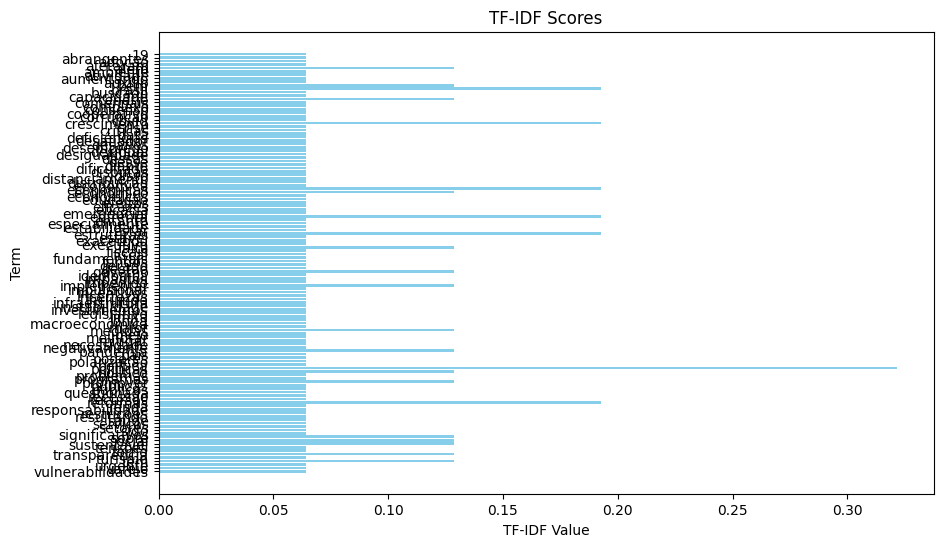

In [ ]:
texto_tratado = ' '.join(texto_filtrado)

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Criar o vetorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Calcular o TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform([texto_tratado])

# Obter os termos e seus respectivos valores de TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
dense_matrix = tfidf_matrix.todense()
tfidf_values = [dense_matrix[0, i] for i in range(len(feature_names))]

# Plotagem do resultado do processamento TF-IDF
plt.figure(figsize=(10, 6))
plt.barh(feature_names, tfidf_values, color='skyblue')
plt.xlabel('TF-IDF Value')
plt.ylabel('Term')
plt.title('TF-IDF Scores')
plt.gca().invert_yaxis()  # Inverter eixo y para os termos aparecerem na ordem correta
plt.show()

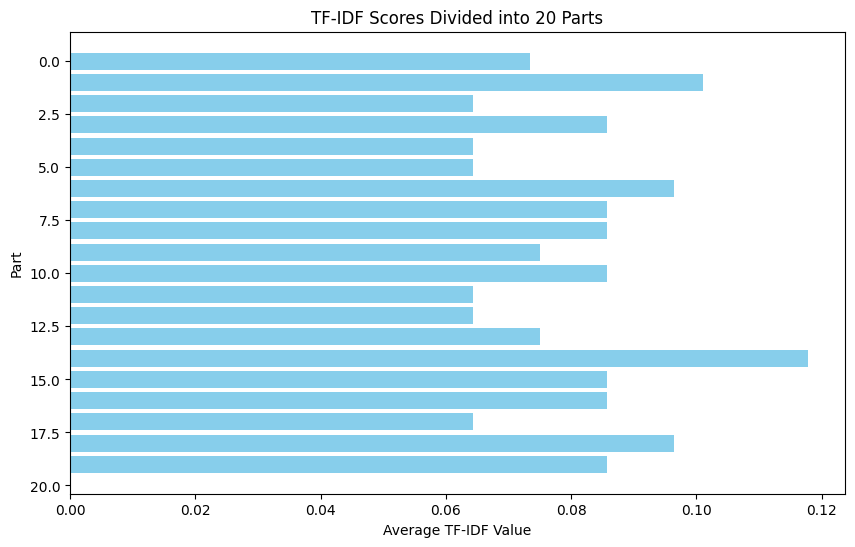

In [ ]:
#  Neste código, usamos a biblioteca NumPy para dividir os valores de TF-IDF em 20 partes aproximadamente iguais
# usando a função np.array_split(). Em seguida, calculamos a média de cada parte e plotamos esses valores em um
# gráfico de barras. Cada barra no gráfico representa a média dos valores de TF-IDF em uma das 20 partes.

import numpy as np

# Dividir os valores de TF-IDF em 20 partes aproximadamente iguais
tfidf_values = np.array(tfidf_values)
tfidf_parts = np.array_split(tfidf_values, 20)

# Calcular a média de cada parte
tfidf_means = [np.mean(part) for part in tfidf_parts]

# Plotagem do resultado dividido em 20 partes
plt.figure(figsize=(10, 6))
plt.barh(range(20), tfidf_means, color='skyblue')
plt.xlabel('Average TF-IDF Value')
plt.ylabel('Part')
plt.title('TF-IDF Scores Divided into 20 Parts')
plt.gca().invert_yaxis()  # Inverter eixo y para a parte 0 estar no topo
plt.show()